In [1]:
from collections import defaultdict
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pyBioInfo.IO.File import BedFile
from Bio.Seq import Seq
from pyBioInfo.IO.File import FastaFile

# Select some transcripts to show the advanced of full-length sequencing

In [2]:
adata1 = sc.read_h5ad("results/h5ad_clustered/Blastocyst.gene_based.h5ad")
adata2 = sc.read_h5ad("results/h5ad_clustered/Blastocyst.transcript_based.h5ad")

In [3]:
with BedFile("../../../1_NanoNASCseq/results/7_assembly_custom/5_gtf_full/MouseBlastocyst.bed.gz") as f:
    transcripts = {t.name: t for t in f}

In [4]:
with FastaFile("/home/chenzonggui/species/mus_musculus/GRCm38.p6/GRCm38.canonical.genome.fa") as fasta:
    for t in transcripts.values():
        cds = None
        if t.thick:
            seq = fasta.fast_fetch(obj=t)
            i1, i2, i3, i4 = t.indexes()
            cds = seq[i2:i3]
        t.cds = cds

Sparc-CDS-1
Sparc-CDS-2
retained_intron
Sparc-CDS-3
Sparc-CDS-1
Lama1-CDS-1
retained_intron
Serpinh1-CDS-1
Serpinh1-CDS-1
Serpinh1-CDS-1
Serpinh1-CDS-1
Col4a1-CDS-1
retained_intron
Lamc1-CDS-1
retained_intron
Apoe-CDS-1
Apoe-CDS-1
Apoe-CDS-2
retained_intron
Mylpf-CDS-1
Mylpf-CDS-2
Mylpf-CDS-3
Tdh-CDS-1
Tdh-CDS-2
Septin1-CDS-1
retained_intron
retained_intron
retained_intron
Hspb1-CDS-1
Hspb1-CDS-2
Cystm1-CDS-1
Cystm1-CDS-2
Cystm1-CDS-3
Cystm1-CDS-1
Dkkl1-CDS-1
Dkkl1-CDS-2
retained_intron
Dkkl1-CDS-3
Myl12b-CDS-1
retained_intron


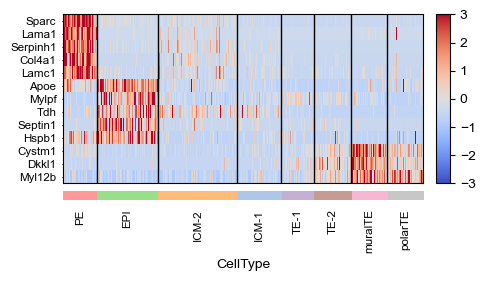

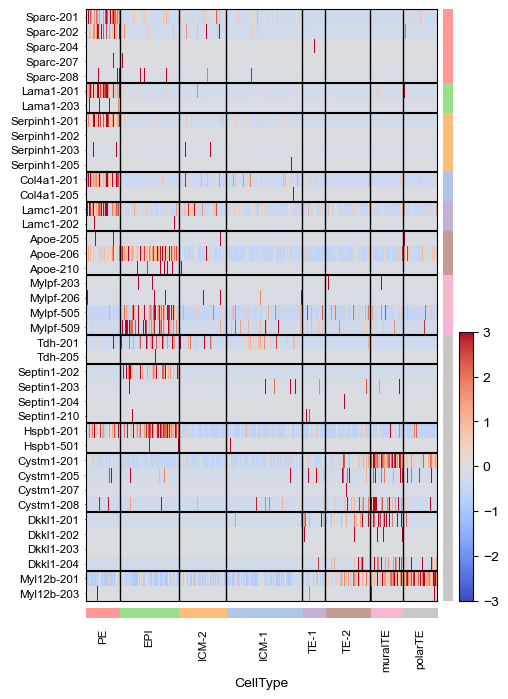

In [5]:
tnames = {
    "Sparc": ["Sparc-201", "Sparc-202", "Sparc-204", "Sparc-207", "Sparc-208"],
    "Lama1": ["Lama1-201", "Lama1-203"],
    "Serpinh1": ["Serpinh1-201", "Serpinh1-202", "Serpinh1-203", "Serpinh1-205"],
    "Col4a1": ["Col4a1-201", "Col4a1-205"],
    "Lamc1": ["Lamc1-201", "Lamc1-202"],
    "Apoe": ["Apoe-205", "Apoe-206", "Apoe-210"],
    "Mylpf": ["Mylpf-203", "Mylpf-206", "Mylpf-505", "Mylpf-509"],
    "Tdh": ["Tdh-201", "Tdh-205"],
    "Septin1": ["Septin1-202", "Septin1-203", "Septin1-204", "Septin1-210"],
    "Hspb1": ["Hspb1-201", "Hspb1-501"],
    "Cystm1": ["Cystm1-201", "Cystm1-205", "Cystm1-207", "Cystm1-208"],
    "Dkkl1": ["Dkkl1-201", "Dkkl1-202", "Dkkl1-203", "Dkkl1-204"],
    "Myl12b": ["Myl12b-201", "Myl12b-203"],
}

gnames = list(tnames.keys())

# Annotate CDS
tnames3 = []
for gname, tnames2 in tnames.items():
    tnames3.extend(tnames2)
tmp = adata2.var
tmp = tmp.loc[tnames3].copy()
for gid, tmp2 in tmp.groupby(by="GeneID"):
    if len(tmp2) == 0:
        continue
    gname = tmp2["GeneName"].values[0]
    mapper = dict()
    n = 1
    for tid in tmp2["TranscriptID"]:
        t = transcripts[tid]
        t.cds_name = None
        if t.cds is not None:
            if t.cds not in mapper:
                mapper[t.cds] = "%s-CDS-%d" % (gname, n)
                n += 1
            t.cds_name = mapper[t.cds]

for tname in tnames3:
    tid = tmp.loc[tname]["TranscriptID"]
    s = transcripts[tid].cds_name
    if not isinstance(s, str):
        s = tmp.loc[tname]["TranscriptType"]
    # print(tname, s, sep="\t")
    print(s)

# Gene-based

ret = sc.pl.heatmap(
    adata1, 
    gnames, 
    groupby="CellType", 
    dendrogram=False, 
    swap_axes=True, 
    layer="scaled", 
    vmin=-3, 
    vmax=3, 
    cmap="coolwarm", 
    show_gene_labels=True, show=False, save=False,
    figsize=(5, 2.5))
ax = ret["heatmap_ax"]

# Transcript-based

ret = sc.pl.heatmap(
    adata2, 
    tnames, 
    groupby="CellType", 
    dendrogram=False, 
    swap_axes=True, 
    layer="scaled", 
    vmin=-3, 
    vmax=3, 
    cmap="coolwarm", 
    show_gene_labels=True, show=False, save=False,
    figsize=(5, 8))
ax = ret["heatmap_ax"]

y = 0
for k, v in tnames.items():
    if y > 0:
        ax.axhline(y - 0.5, color="black")
    y += len(v)

In [6]:
tmp

,TranscriptID,TranscriptType,GeneID,GeneName,GeneType,Chrom,Start,End,Strand,n_cells,highly_variable,means,dispersions,dispersions_norm
TranscriptName,,,,,,,,,,,,,,
Sparc-201,ENSMUST00000018737.12,protein_coding,ENSMUSG00000018593.13,Sparc,protein_coding,chr11,55394499,55420080,-,675,True,0.640988,1.999369,4.853320
Sparc-202,ENSMUST00000108858.7,protein_coding,ENSMUSG00000018593.13,Sparc,protein_coding,chr11,55394499,55419898,-,256,False,0.147191,0.895780,2.048644
Sparc-204,ENSMUST00000125787.1,retained_intron,ENSMUSG00000018593.13,Sparc,protein_coding,chr11,55409203,55419900,-,4,False,0.001241,0.085522,-0.380811
Sparc-207,ENSMUST00000213866.1,protein_coding,ENSMUSG00000018593.13,Sparc,protein_coding,chr11,55395420,55420290,-,9,False,0.003796,0.110863,-0.304830
Sparc-208,ENSMUST00000214685.1,protein_coding,ENSMUSG00000018593.13,Sparc,protein_coding,chr11,55395420,55423183,-,61,False,0.024262,0.311307,0.296176
Lama1-201,ENSMUST00000035471.8,protein_coding,ENSMUSG00000032796.8,Lama1,protein_coding,chr17,67697258,67822647,+,382,True,0.398371,1.949146,6.837551
Lama1-203,ENSMUST00000233821.1,retained_intron,ENSMUSG00000032796.8,Lama1,protein_coding,chr17,67697264,67756912,+,29,False,0.013952,0.520002,0.921919
Serpinh1-201,ENSMUST00000094154.5,protein_coding,ENSMUSG00000070436.12,Serpinh1,protein_coding,chr7,99345388,99353239,-,316,True,0.280639,1.535150,4.903474
Serpinh1-202,ENSMUST00000169437.8,protein_coding,ENSMUSG00000070436.12,Serpinh1,protein_coding,chr7,99345375,99353114,-,10,False,0.003535,0.095333,-0.351397


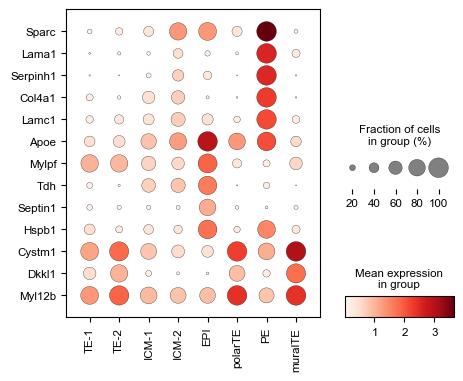

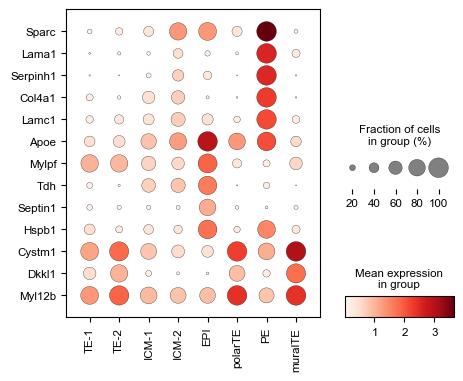

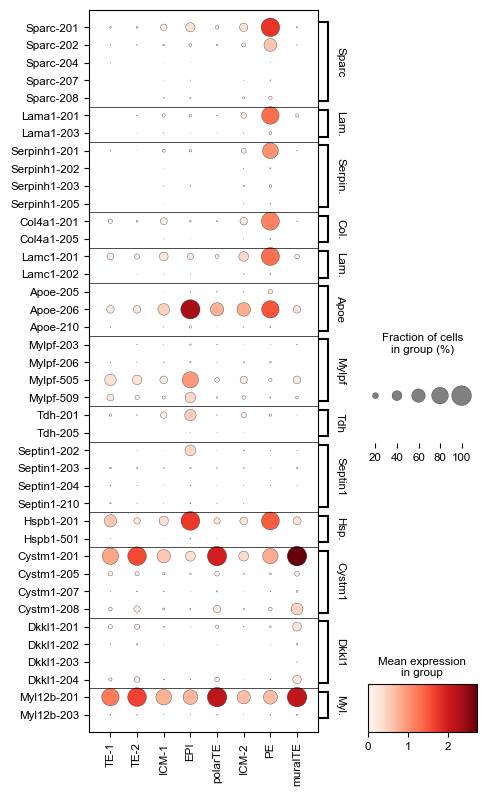

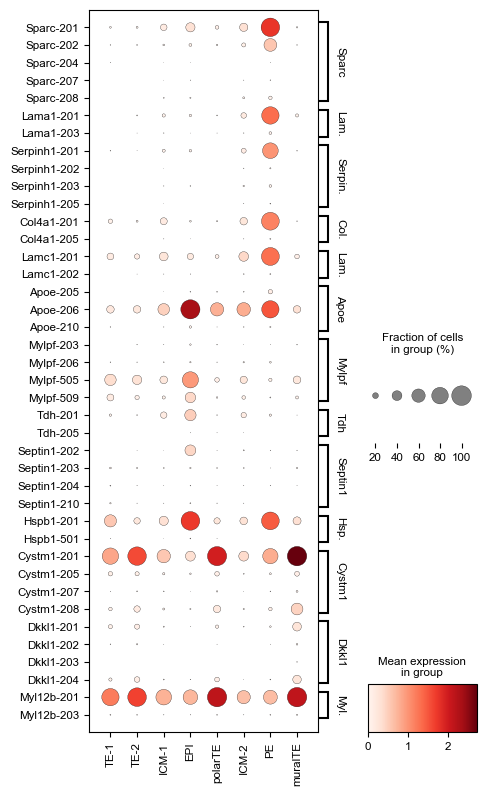

In [7]:
# Gene-based

ret = sc.pl.dotplot(adata1, gnames, groupby="CellType", swap_axes=True, figsize=(5, 4), show=False, return_fig=True)
ax = ret.get_axes()["mainplot_ax"]
ret.show()

# Transcript-based

ret = sc.pl.dotplot(adata2, tnames, groupby="CellType", swap_axes=True, figsize=(5, 9), show=False, return_fig=True)
ax = ret.get_axes()["mainplot_ax"]
y = 0
for k, v in tnames.items():
    if y > 0:
        ax.axhline(y, color="black", lw=0.5)
    y += len(v)
ret.show()

In [8]:
adata = sc.read_h5ad("results/h5ad_clustered/Blastocyst.transcript_based.h5ad")

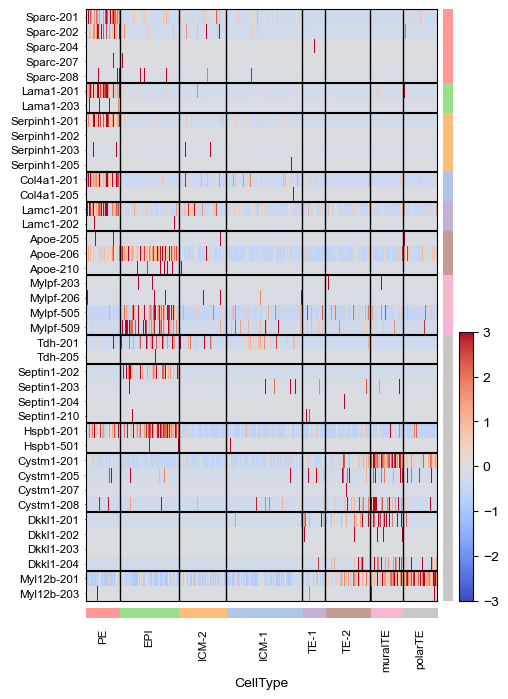

In [14]:
tnames = {
    "Sparc": ["Sparc-201", "Sparc-202", "Sparc-204", "Sparc-207", "Sparc-208"],
    "Lama1": ["Lama1-201", "Lama1-203"],
    "Serpinh1": ["Serpinh1-201", "Serpinh1-202", "Serpinh1-203", "Serpinh1-205"],
    "Col4a1": ["Col4a1-201", "Col4a1-205"],
    "Lamc1": ["Lamc1-201", "Lamc1-202"],
    "Apoe": ["Apoe-205", "Apoe-206", "Apoe-210"],
    "Mylpf": ["Mylpf-203", "Mylpf-206", "Mylpf-505", "Mylpf-509"],
    "Tdh": ["Tdh-201", "Tdh-205"],
    "Septin1": ["Septin1-202", "Septin1-203", "Septin1-204", "Septin1-210"],
    "Hspb1": ["Hspb1-201", "Hspb1-501"],
    "Cystm1": ["Cystm1-201", "Cystm1-205", "Cystm1-207", "Cystm1-208"],
    "Dkkl1": ["Dkkl1-201", "Dkkl1-202", "Dkkl1-203", "Dkkl1-204"],
    "Myl12b": ["Myl12b-201", "Myl12b-203"],
}

ret = sc.pl.heatmap(
    adata, 
    tnames, 
    groupby="CellType", 
    dendrogram=False, 
    swap_axes=True, 
    layer="scaled", 
    vmin=-3, 
    vmax=3, 
    cmap="coolwarm", 
    show_gene_labels=True, show=False, save=False,
    figsize=(5, 8))
ax = ret["heatmap_ax"]

y = 0
for k, v in tnames.items():
    if y > 0:
        ax.axhline(y - 0.5, color="black")
    y += len(v)



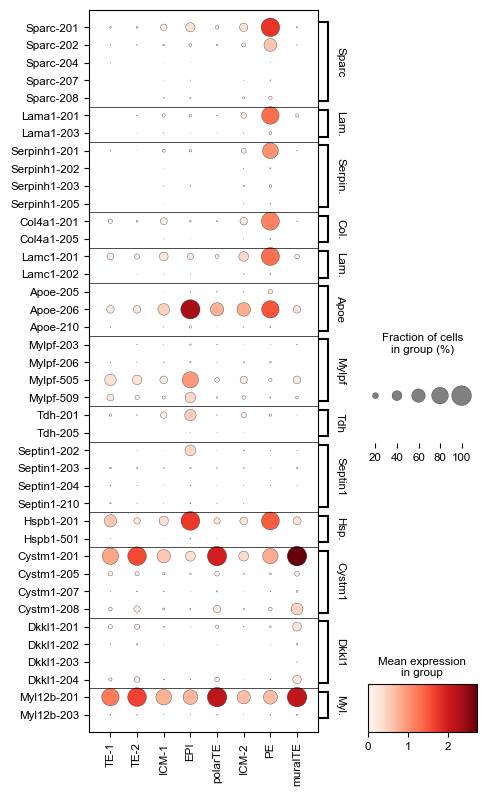

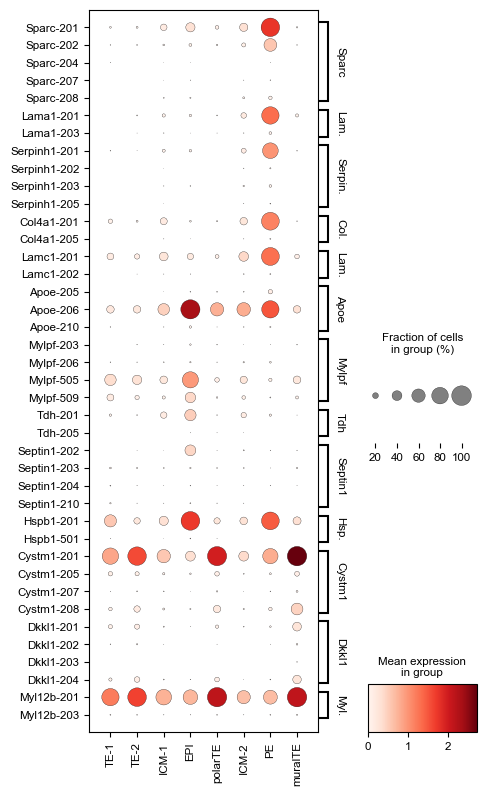

In [15]:
ret = sc.pl.dotplot(adata, tnames, groupby="CellType", swap_axes=True, figsize=(5, 9), show=False, return_fig=True)
ax = ret.get_axes()["mainplot_ax"]
y = 0
for k, v in tnames.items():
    if y > 0:
        ax.axhline(y, color="black", lw=0.5)
    y += len(v)
# ret.savefig("a.pdf")
ret.show()

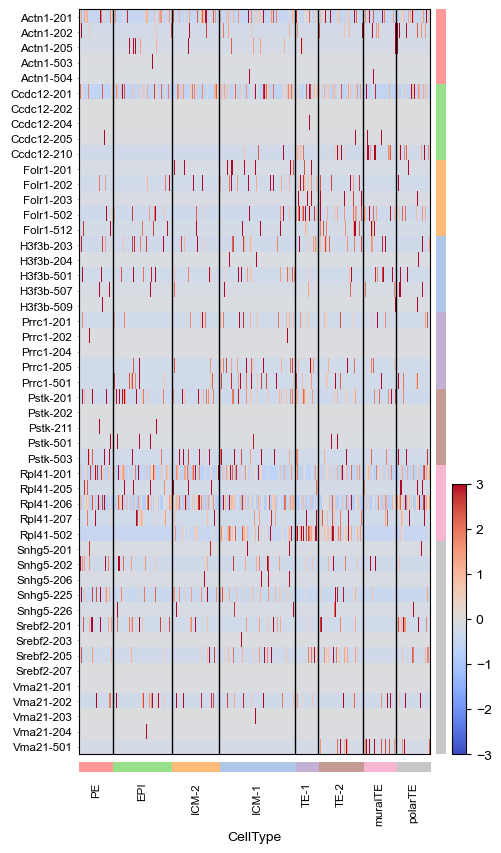

In [11]:
tnames = {
    'Actn1': ['Actn1-201', 'Actn1-202', 'Actn1-205', 'Actn1-503', 'Actn1-504'],
    'Ccdc12': ['Ccdc12-201', 'Ccdc12-202', 'Ccdc12-204', 'Ccdc12-205', 'Ccdc12-210'],
    'Folr1': ['Folr1-201', 'Folr1-202', 'Folr1-203', 'Folr1-502', 'Folr1-512'],
    'H3f3b': ['H3f3b-203', 'H3f3b-204', 'H3f3b-501', 'H3f3b-507', 'H3f3b-509'],
    'Prrc1': ['Prrc1-201', 'Prrc1-202', 'Prrc1-204', 'Prrc1-205', 'Prrc1-501'],
    'Pstk': ['Pstk-201', 'Pstk-202', 'Pstk-211', 'Pstk-501', 'Pstk-503'],
    'Rpl41': ['Rpl41-201', 'Rpl41-205', 'Rpl41-206', 'Rpl41-207', 'Rpl41-502'],
    'Snhg5': ['Snhg5-201', 'Snhg5-202', 'Snhg5-206', 'Snhg5-225', 'Snhg5-226'],
    'Srebf2': ['Srebf2-201', 'Srebf2-203', 'Srebf2-205', 'Srebf2-207'],
    'Vma21': ['Vma21-201', 'Vma21-202', 'Vma21-203', 'Vma21-204', 'Vma21-501']
}

ax = sc.pl.heatmap(
    adata, 
    tnames, 
    groupby="CellType", 
    dendrogram=False, 
    swap_axes=True, 
    layer="scaled", 
    vmin=-3, 
    vmax=3, 
    cmap="coolwarm", 
    show_gene_labels=True, 
    figsize=(5, 10))